# Task 02 - Graph Representation and Analysis

In [1]:
import sys
from pathlib import Path

# Make the project root importable when running locally
PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import RAW_DATA_DIR, RESULTS_DIR
from src.data import load_ogbn_arxiv
from src.graph.graph_analysis import graph_summary
from src.graph.visualization import plot_sample_subgraph
import pandas as pd

dataset, data, splits = load_ogbn_arxiv(RAW_DATA_DIR)
summary = graph_summary(data)
summary


C:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ogb\nodeproppred\dataset_pyg.py:91: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  train_idx = torch.from_numpy(pd.read_csv(osp.join(path, 'train.csv.gz'), compression='gzip', header = None).values.T[0]).to(torch.long)


{'nodes': 169343,
 'edges': 2315598,
 'features': 128,
 'density': 0.00016149579827340663,
 'min_degree': 1.0,
 'max_degree': 13161.0,
 'mean_degree': 13.674010276794434,
 'median_degree': 6.0}

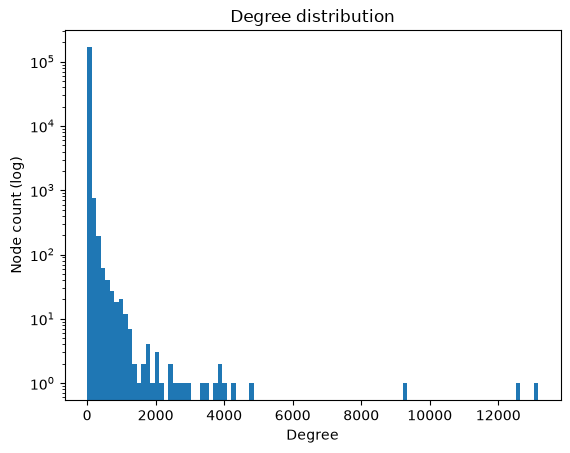

In [2]:
out = RESULTS_DIR / 'graph_analysis'
out.mkdir(parents=True, exist_ok=True)
pd.DataFrame([summary]).to_csv(out / 'graph_summary.csv', index=False)
(out / 'graph_density.txt').write_text(f"Graph density: {summary['density']:.8f}\n")
plot_sample_subgraph(data, out / 'sample_subgraph.png')

import matplotlib.pyplot as plt
degrees = data.edge_index[0].bincount(minlength=data.num_nodes).cpu().numpy()
plt.hist(degrees, bins=100, log=True)
plt.xlabel('Degree')
plt.ylabel('Node count (log)')
plt.title('Degree distribution')
plt.savefig(out / 'degree_distribution.png', dpi=180, bbox_inches='tight')
plt.show()